# 04 - Upstream Gauge Analysis

Identifies which Google flood forecast gauges are upstream of each selected LGA using HydroBASINS level 12 network topology and a recursive backward traversal algorithm. Gauges on all rivers (including tributaries) and in upstream countries are included.
Also computes a `hop_distance` for each gauge — the minimum number of NEXT_DOWN basin steps separating the gauge from the LGA — as a proxy for upstream distance.

**Outputs saved to Azure:**
- `ds-aa-nga-flooding/processed/sel_lga_upstream_gauges.parquet` — Upstream gauge–LGA pairs with river name, quality verification status, and hop distance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.datasources import grrr, nihsa, hydrosheds

load_dotenv()

COLOR_PRIMARY = "#007CE0"
COLOR_CORAL = "#F2645A"
COLOR_TEAL = "#1EBFB3"
COLOR_GRAY = "#666666"

In [ ]:
import io
import tempfile
import zipfile

gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas.parquet"
)

gdf_hydrological_areas = nihsa.load_hydological_areas().set_crs(epsg=4326)

# Buffer hydrological areas by 200km to capture upstream gauges outside Nigeria
gdf_ha_buffered = gpd.GeoDataFrame(
    geometry=[
        gdf_hydrological_areas
        .to_crs(epsg=26392)
        .buffer(200_000)
        .to_crs(epsg=4326)
        .union_all()
    ],
    crs="EPSG:4326"
)

gdf_gauges = grrr.get_gauges_by_area(
    gdf_ha_buffered,
    include_non_quality_verified=True
)

# Diagnostic: show river names for gauges outside Nigeria's bounding box
# to catch alternate spellings (e.g. French "Bénoué" for Benue in Cameroon)
nigeria_bbox_lon = (2.5, 15.0)
nigeria_bbox_lat = (3.0, 14.5)
gauges_outside_nigeria = gdf_gauges[
    ~(
        gdf_gauges.longitude.between(*nigeria_bbox_lon) &
        gdf_gauges.latitude.between(*nigeria_bbox_lat)
    )
]
print("River names for gauges outside Nigeria:")
print(gauges_outside_nigeria["river"].value_counts().to_string())

gdf_gauges_verified = gdf_gauges[gdf_gauges.river.isin(["Niger", "Benue", "Bénoué", "Benoue", "Sokoto"])].copy()

# Include quality-verified gauges with empty river names near the Benue (in Cameroon).
# Download HydroRIVERS GDB from Azure, extract, and read only the Benue-area bbox.
gdf_empty_river_qv = gdf_gauges[
    (gdf_gauges.river.fillna("").str.strip() == "") & gdf_gauges.quality_verified
].copy()

if len(gdf_empty_river_qv) > 0:
    blob_data = stratus.load_blob_data("ds-aa-nga-flooding/raw/hydrosheds/HydroRIVERS_v10_af.gdb.zip")
    benue_bbox = (7.5, 6.5, 16.0, 10.5)  # covers Benue watershed into Cameroon
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(io.BytesIO(blob_data), "r") as zip_ref:
            zip_ref.extractall(tmpdir)
        gdf_rivers_area = gpd.read_file(
            f"{tmpdir}/HydroRIVERS_v10_af.gdb", bbox=benue_bbox
        )
    gdf_benue = gdf_rivers_area[
        (gdf_rivers_area["MAIN_RIV"] == 10877687) &
        (gdf_rivers_area.geometry.centroid.y < 10)
    ]
    # Buffer Benue by 15 km to catch nearby gauges with missing river labels
    benue_buffer = (
        gdf_benue
        .to_crs(epsg=32633)
        .buffer(15_000)
        .to_crs(epsg=4326)
        .union_all()
    )
    gdf_benue_unlabelled = gdf_empty_river_qv[
        gdf_empty_river_qv.geometry.within(benue_buffer)
    ].copy()
    print(f"\nUnlabelled quality-verified gauges near Benue added: {len(gdf_benue_unlabelled)}")
    gdf_gauges_verified = pd.concat(
        [gdf_gauges_verified, gdf_benue_unlabelled], ignore_index=True
    )

gdf_basins = hydrosheds.load_basins(level=12).set_crs(epsg=4326)
# Expand bbox to cover upstream countries:
# - Niger headwaters in Guinea/Mali (~-15E to 3E)
# - Benue headwaters in Cameroon (~14E, extending to 16E)
upstream_bbox = (-15, 3, 16, 16)
gdf_basins_ng = gdf_basins.cx[upstream_bbox[0]:upstream_bbox[2], upstream_bbox[1]:upstream_bbox[3]].copy()
gdf_nigeria = gdf_hydrological_areas.dissolve()

print(f"\nLGAs: {len(gdf_lga_sel)}, Gauges: {len(gdf_gauges_verified)}, Basins: {len(gdf_basins_ng)}")

<Axes: >

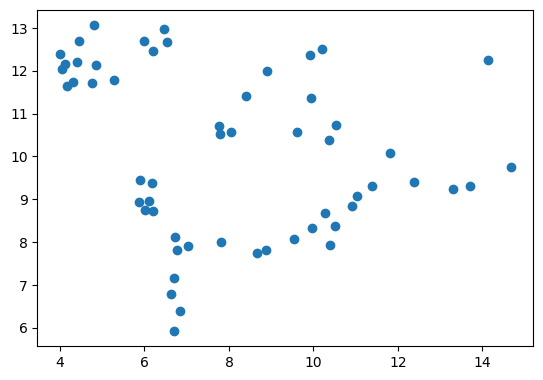

In [4]:
gdf_gauges[gdf_gauges.quality_verified].plot()

In [5]:
gdf_gauges_with_basin = gpd.sjoin(
    gdf_gauges_verified,
    gdf_basins_ng[["HYBAS_ID", "NEXT_DOWN", "MAIN_BAS", "geometry"]],
    how="left",
    predicate="within"
)

gdf_lga_with_basins = gpd.sjoin(
    gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "HA_assigned", "geometry"]],
    gdf_basins_ng[["HYBAS_ID", "NEXT_DOWN", "MAIN_BAS", "geometry"]],
    how="left",
    predicate="intersects"
)

In [6]:
from collections import deque

# Pre-compute reverse lookup once — reused by both functions below
reverse_lookup = gdf_basins_ng.groupby("NEXT_DOWN")["HYBAS_ID"].apply(list).to_dict()


def find_upstream_basins(target_basin_id, reverse_lookup):
    """Find all basins upstream of a target basin using recursive backward traversal."""
    upstream = set()

    def recurse(node_id):
        for parent in reverse_lookup.get(node_id, []):
            if parent not in upstream:
                upstream.add(parent)
                recurse(parent)

    recurse(target_basin_id)
    return upstream


def compute_hop_distances(target_basin_ids, reverse_lookup):
    """
    BFS backward from a set of target basins (the LGA's own basins).
    Returns {basin_id: min_hop_count} for every reachable upstream basin.

    Target basins themselves are included with hop_distance=0. This covers
    gauges that sit within the LGA's own basins — reachable because an LGA
    can span many basins, some of which are upstream of others within the LGA.

    Hop count = number of NEXT_DOWN steps separating the upstream basin
    from the nearest target basin — a proxy for upstream distance.
    Note: gauges on different tributaries may share the same hop count
    while being far apart geographically.
    """
    # Seed target basins at distance 0
    distances = {bid: 0 for bid in target_basin_ids}
    visited = set(target_basin_ids)
    queue = deque((bid, 0) for bid in target_basin_ids)

    while queue:
        node_id, dist = queue.popleft()
        for parent in reverse_lookup.get(node_id, []):
            if parent not in visited:
                visited.add(parent)
                distances[parent] = dist + 1
                queue.append((parent, dist + 1))

    return distances

In [7]:
upstream_relationships = []

for lga_pcode, lga_basins in gdf_lga_with_basins.groupby("ADM2_PCODE"):
    lga_info = lga_basins.iloc[0]
    lga_basin_ids = lga_basins["HYBAS_ID"].dropna().unique()

    if len(lga_basin_ids) == 0:
        continue

    all_upstream_basin_ids = set()
    for basin_id in lga_basin_ids:
        all_upstream_basin_ids.update(find_upstream_basins(basin_id, reverse_lookup))

    # BFS hop distances from this LGA's basins to all upstream basins
    hop_distances = compute_hop_distances(set(lga_basin_ids), reverse_lookup)

    for _, gauge in gdf_gauges_with_basin.iterrows():
        gauge_basin_id = gauge["HYBAS_ID"]
        if pd.isna(gauge_basin_id):
            continue
        if gauge_basin_id in all_upstream_basin_ids:
            upstream_relationships.append({
                "lga_pcode": lga_pcode,
                "lga_name": lga_info["ADM2_EN"],
                "lga_num_basins": len(lga_basin_ids),
                "lga_ha": lga_info["HA_assigned"],
                "gauge_id": gauge["gauge_id"],
                "gauge_site": gauge["site_name"],
                "gauge_river": gauge["river"],
                "gauge_basin_id": gauge_basin_id,
                "quality_verified": gauge["quality_verified"],
                "hop_distance": hop_distances.get(int(gauge_basin_id)),
            })

df_upstream = pd.DataFrame(upstream_relationships)

print(f"Upstream gauge-LGA pairs: {len(df_upstream)}")
print(f"LGAs with upstream gauges: {df_upstream['lga_pcode'].nunique()} / {len(gdf_lga_sel)}")
print(f"Unique upstream gauges: {df_upstream['gauge_id'].nunique()}")

Upstream gauge-LGA pairs: 9197
LGAs with upstream gauges: 67 / 73
Unique upstream gauges: 267


/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_70775/3315013680.py:41: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", fontsize=10)


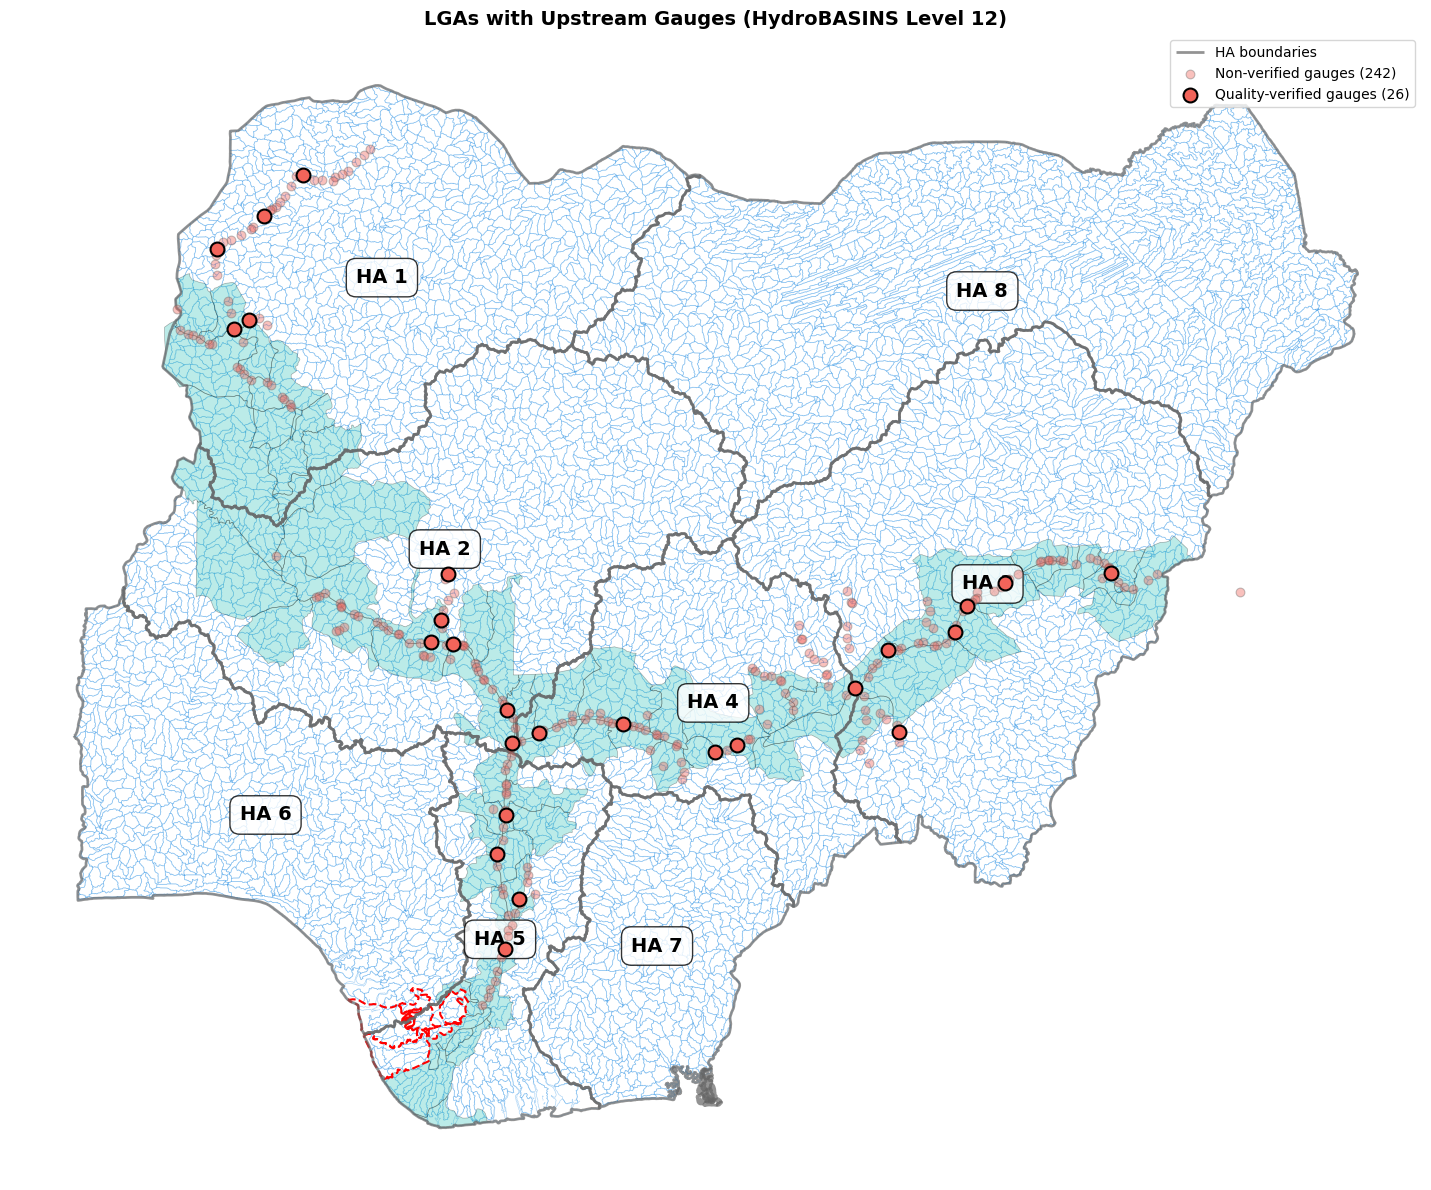

In [8]:
nigeria_boundary = gdf_nigeria.geometry.iloc[0]
gdf_rivers_clipped = gdf_basins_ng.copy()
gdf_rivers_clipped["geometry"] = gdf_rivers_clipped.geometry.intersection(nigeria_boundary)
gdf_rivers_clipped = gdf_rivers_clipped[~gdf_rivers_clipped.geometry.is_empty]

gdf_gauges_qv = gdf_gauges_verified[gdf_gauges_verified["quality_verified"]].copy()
gdf_gauges_non_qv = gdf_gauges_verified[~gdf_gauges_verified["quality_verified"]].copy()

fig, ax = plt.subplots(figsize=(16, 12))

gdf_hydrological_areas.boundary.plot(ax=ax, color=COLOR_GRAY, linewidth=2, alpha=0.7, label="HA boundaries")
gdf_rivers_clipped.plot(ax=ax, facecolor="none", edgecolor=COLOR_PRIMARY, linewidth=0.5, alpha=0.3, label="River basins")

if len(df_upstream) > 0:
    lgas_with_gauges = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(df_upstream["lga_pcode"])]
    lgas_with_gauges.plot(ax=ax, facecolor=COLOR_TEAL, alpha=0.3, edgecolor="black", linewidth=0.5, label="LGAs with upstream gauges")
    lgas_without = gdf_lga_sel[~gdf_lga_sel["ADM2_PCODE"].isin(df_upstream["lga_pcode"])]
    if len(lgas_without) > 0:
        lgas_without.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5, linestyle="--", label="LGAs without upstream gauges")

# Non-quality-verified gauges: smaller, transparent, grey border
gdf_gauges_non_qv.plot(
    ax=ax, color=COLOR_CORAL, markersize=40, alpha=0.4,
    edgecolor=COLOR_GRAY, linewidth=0.8,
    label=f"Non-verified gauges ({len(gdf_gauges_non_qv)})", zorder=4
)
# Quality-verified gauges: larger, solid, dark border
gdf_gauges_qv.plot(
    ax=ax, color=COLOR_CORAL, markersize=100, alpha=1.0,
    edgecolor="black", linewidth=1.5,
    label=f"Quality-verified gauges ({len(gdf_gauges_qv)})", zorder=5
)

for idx, row in gdf_hydrological_areas.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"HA {row['HA']}",
            fontsize=14, fontweight="bold", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="black"))

ax.set_title("LGAs with Upstream Gauges (HydroBASINS Level 12)", fontweight="bold", fontsize=14)
ax.legend(loc="upper right", fontsize=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(Path("figures/lga_upstream_gauges.png"), dpi=300, bbox_inches="tight")
# plt.show()

In [ ]:
stratus.upload_parquet_to_blob(df_upstream, "ds-aa-nga-flooding/processed/sel_lga_upstream_gauges.parquet")

In [43]:
df_upstream

,lga_pcode,lga_name,lga_num_basins,lga_ha,gauge_id,gauge_site,gauge_river,gauge_basin_id,quality_verified,hop_distance
0,NG002001,Demsa,23,3,hybas_1120837770,,Benue,1.120838e+09,False,0
1,NG002001,Demsa,23,3,hybas_1120840560,,Benue,1.120841e+09,False,1
2,NG002001,Demsa,23,3,hybas_1120840690,,Benue,1.120841e+09,False,1
3,NG002001,Demsa,23,3,hybas_1120840700,,Benue,1.120841e+09,False,2
4,NG002001,Demsa,23,3,hybas_1120842550,,Benue,1.120843e+09,True,3
...,...,...,...,...,...,...,...,...,...,...
9275,NG035014,Wukari,47,4,hybas_1121992370,,Benue,1.121992e+09,False,0
9276,NG035014,Wukari,47,4,hybas_1121993040,,Benue,1.121993e+09,False,2
9277,NG035014,Wukari,47,4,hybas_1121993110,,Benue,1.121993e+09,False,2
9278,NG035014,Wukari,47,4,hybas_1120813740,,,1.120814e+09,True,48


In [42]:
lgas_with_gauges = gdf_lga_sel[
    gdf_lga_sel["ADM2_PCODE"].isin(df_upstream["lga_pcode"])
].copy()

print(f"LGAs with upstream gauges: {len(lgas_with_gauges)} / {len(gdf_lga_sel)}")

stratus.upload_parquet_to_blob(
    lgas_with_gauges,
    "ds-aa-nga-flooding/processed/selected_lgas_with_upstream_gauges.parquet"
)

LGAs with upstream gauges: 67 / 73
